# Ocean heat content — alternate spin-ups vs Full-CPL

Figures:
* `ocean_ohc_diag_Global_ts_yr0001-0350.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

from dataclasses import dataclass, asdict
from typing import Optional, Sequence, Tuple, Union, Literal, Iterable, List, Dict, Optional, Any
import os, re, glob
import numpy as np
import xarray as xr
import cftime
import math 
import json
import pandas as pd  
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats, signal
from matplotlib.ticker import (
    FixedLocator, FixedFormatter, AutoMinorLocator,
    MultipleLocator, NullFormatter
)
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

from util.alt_global_timeseries import OHCDiagnosticsPlotter, OHCFigureDataCollector, OHCFigureDataCollectorConfig
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ohc"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ohc"                   # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)
YEARS       = (1, 350)      # simulation years analysed (selects the MPAS-Analysis ts_0001-0350 run)
SWITCH_YEAR = 221           # vertical marker: first piControl year of the AltBG runs


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc


## 1 OHC time series and depth–time Hovmöller
### Settings

In [4]:
# === Paths ===
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Experiments ===
exp_type   = "spin-up"
exp_tags   = EXPS
labels     = [LABEL[t] for t in EXPS]
ts_colors  = ["black", "#cc0000", "#377eb8"]
hov_cmap   = "RdBu_r"

# shading windows (years) for each experiment tag
exp_shas = {
    "Full-CPL": None,
    "AltBG1": {
        "segments": [(11, 20), (81, 90), (151, 160)],
        "alpha": 0.3,
        "hatch": "///",
        "color": ts_colors[EXPS.index("AltBG1")],   # hatch in the experiment's line color
        "hov_alpha": 0.6,       # same color as the time series, stronger on the RdBu Hovmöller
    },
    "AltBG2": {
        "segments": [(11, 50)],
        "alpha": 0.3,
        "hatch": "..",
        "color": ts_colors[EXPS.index("AltBG2")],   # hatch in the experiment's line color
        "hov_alpha": 0.6,       # same color as the time series, stronger on the RdBu Hovmöller
    },
}

# === Time window ===
calendar  = "noleap"
ts_window = YEARS
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"

# optional plotting padding (your plotter uses these)
year_min_plot, year_max_plot = year_min - 1, year_max + 1
reassign_monthly_time = True

# === OHC from mpas_analysis layer-region ===
ohc_vars = ["OHC_0_bottom", "OHC_0_700", "OHC_700_2000", "OHC_2000_bottom"]
ohc_ts_base  = "post/analysis/mpas_analysis"
ohc_clim_len = 50
ohc_file_key  = "mpasTimeSeriesOcean"
ohc_length_policy = "auto" 

# OHC TS extraction knobs
ohc_anomaly     = True
ohc_to_ZJ       = True
ohc_base_months = 12
ohc_rho         = 1026.0
ohc_cp          = 3996.0
ohc_use_mask_in_volume = True

# extraction cadence (keep monthly here; plotter can annualize)
ohc_annual_mean = False
ohc_annual_weighted = False
ohc_annual_drop_incomplete = True
ohc_annual_min_days = 360

# === OHC Hovmöller extraction ===
hov_key = "OHC_layer"
hov_mode = "total"
hov_to_units = "1e22 J"
hov_anomaly = True
hov_baseline_mode = "first_N"
hov_baseline_months = 12
hov_annual_first = False
hov_annual_weighted = False
hov_annual_drop_incomplete = False
hov_annual_min_days = 360
hov_use_mask_in_area = True
hov_depth_coord = "bottom"
hov_return_cumulative = False
hov_from_top = False

hov_vmin = -8
hov_vmax =  8
hov_spin_year = SWITCH_YEAR

# ============================================================
# Region selection (SINGLE consistent setup for TS + HOV)
# ============================================================
region_key = "Global"
reg_dim = "nOceanRegionsTmp"
reg_var = None  # reserved/unused in collector; kept for consistency
region_index=None 
engine = "netcdf4"
chunks = None
use_mfdataset = True
verbose = True

# ---- plot metadata ----
plot_info = {
    "OHC_0_bottom": dict(
        short=r"$\Delta$OHC" if ohc_anomaly else r"OHC [0-bottom]",
        unit=r"$10^{22}\,\mathrm{J}$" if ohc_to_ZJ else r"$\mathrm{J}$",
        label=r"(d) Ocean Heat Content Anomaly ($\Delta$OHC, 0-bottom)" if ohc_anomaly else r"Ocean Heat Content (0-bottom)",
        ylim=(-60, 60),
        scale=1.0,
    ),
    "OHC_0_700": dict(
        short=r"$\Delta$OHC" if ohc_anomaly else r"OHC [0–700m]",
        unit=r"$10^{22}\,\mathrm{J}$" if ohc_to_ZJ else r"$\mathrm{J}$",
        label=r"(e) Ocean Heat Content Anomaly ($\Delta$OHC, 0–700 m)" if ohc_anomaly else r"Ocean Heat Content (0–700 m)",
        ylim=(-60, 60),
        scale=1.0,
    ),
    "OHC_700_2000": dict(
        short=r"$\Delta$OHC" if ohc_anomaly else r"OHC [700m–2000m]",
        unit=r"$10^{22}\,\mathrm{J}$" if ohc_to_ZJ else r"$\mathrm{J}$",
        label=r"(f) Ocean Heat Content Anomaly ($\Delta$OHC, 700m–2000m)" if ohc_anomaly else r"Ocean Heat Content (700–2000 m)",
        ylim=(-60, 60),
        scale=1.0,
    ),
    "OHC_2000_bottom": dict(
        short=r"$\Delta$OHC" if ohc_anomaly else r"OHC [2000m–bottom]",
        unit=r"$10^{22}\,\mathrm{J}$" if ohc_to_ZJ else r"$\mathrm{J}$",
        label=r"(g) Ocean Heat Content Anomaly ($\Delta$OHC, 2000m–bottom)" if ohc_anomaly else r"Ocean Heat Content (2000 m–bottom)",
        ylim=(-60, 60),
        scale=1.0,
    ),
}

# ============================================================
# Output naming (your convention)
# ============================================================
collect_figure_data = False #True
out_base = f"ocean_ohc_diag_{region_key}_ts_yr{year_min:04d}-{year_max:04d}"
out_ncb  = os.path.join(out_dir, f"{out_base}")        # base for *_ts_*.nc, *_hov_*.nc, *_meta.json
out_pdf  = os.path.join(fig_dir, f"{out_base}.pdf")    # figure

# depth reference file
ohc_depth = f"{OUTPUT_ROOT}/data/grid/depth.nc"
print("[OHC depth file]", ohc_depth)
if not os.path.exists(ohc_depth):
    raise FileNotFoundError(f"[ERROR] depth reference file not found: {ohc_depth}")


[OHC depth file] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/grid_data/depth.nc


### Compute & plot


[OHCDataCollector] loaded TS from: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_alt_ohc/ocean_ohc_diag_Global_ts_yr0001-0350_ts_<exp>.nc
  Full-CPL: ['OHC_0_bottom', 'OHC_0_700', 'OHC_700_2000', 'OHC_2000_bottom']
  AltBG1: ['OHC_0_bottom', 'OHC_0_700', 'OHC_700_2000', 'OHC_2000_bottom']
  AltBG2: ['OHC_0_bottom', 'OHC_0_700', 'OHC_700_2000', 'OHC_2000_bottom']

[OHCDataCollector] loaded HOV from: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_alt_ohc/ocean_ohc_diag_Global_ts_yr0001-0350_hov_<exp>.nc
[saved STATS] /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc/ocean_ohc_diag_Global_ts_yr0001-0350_stats.json


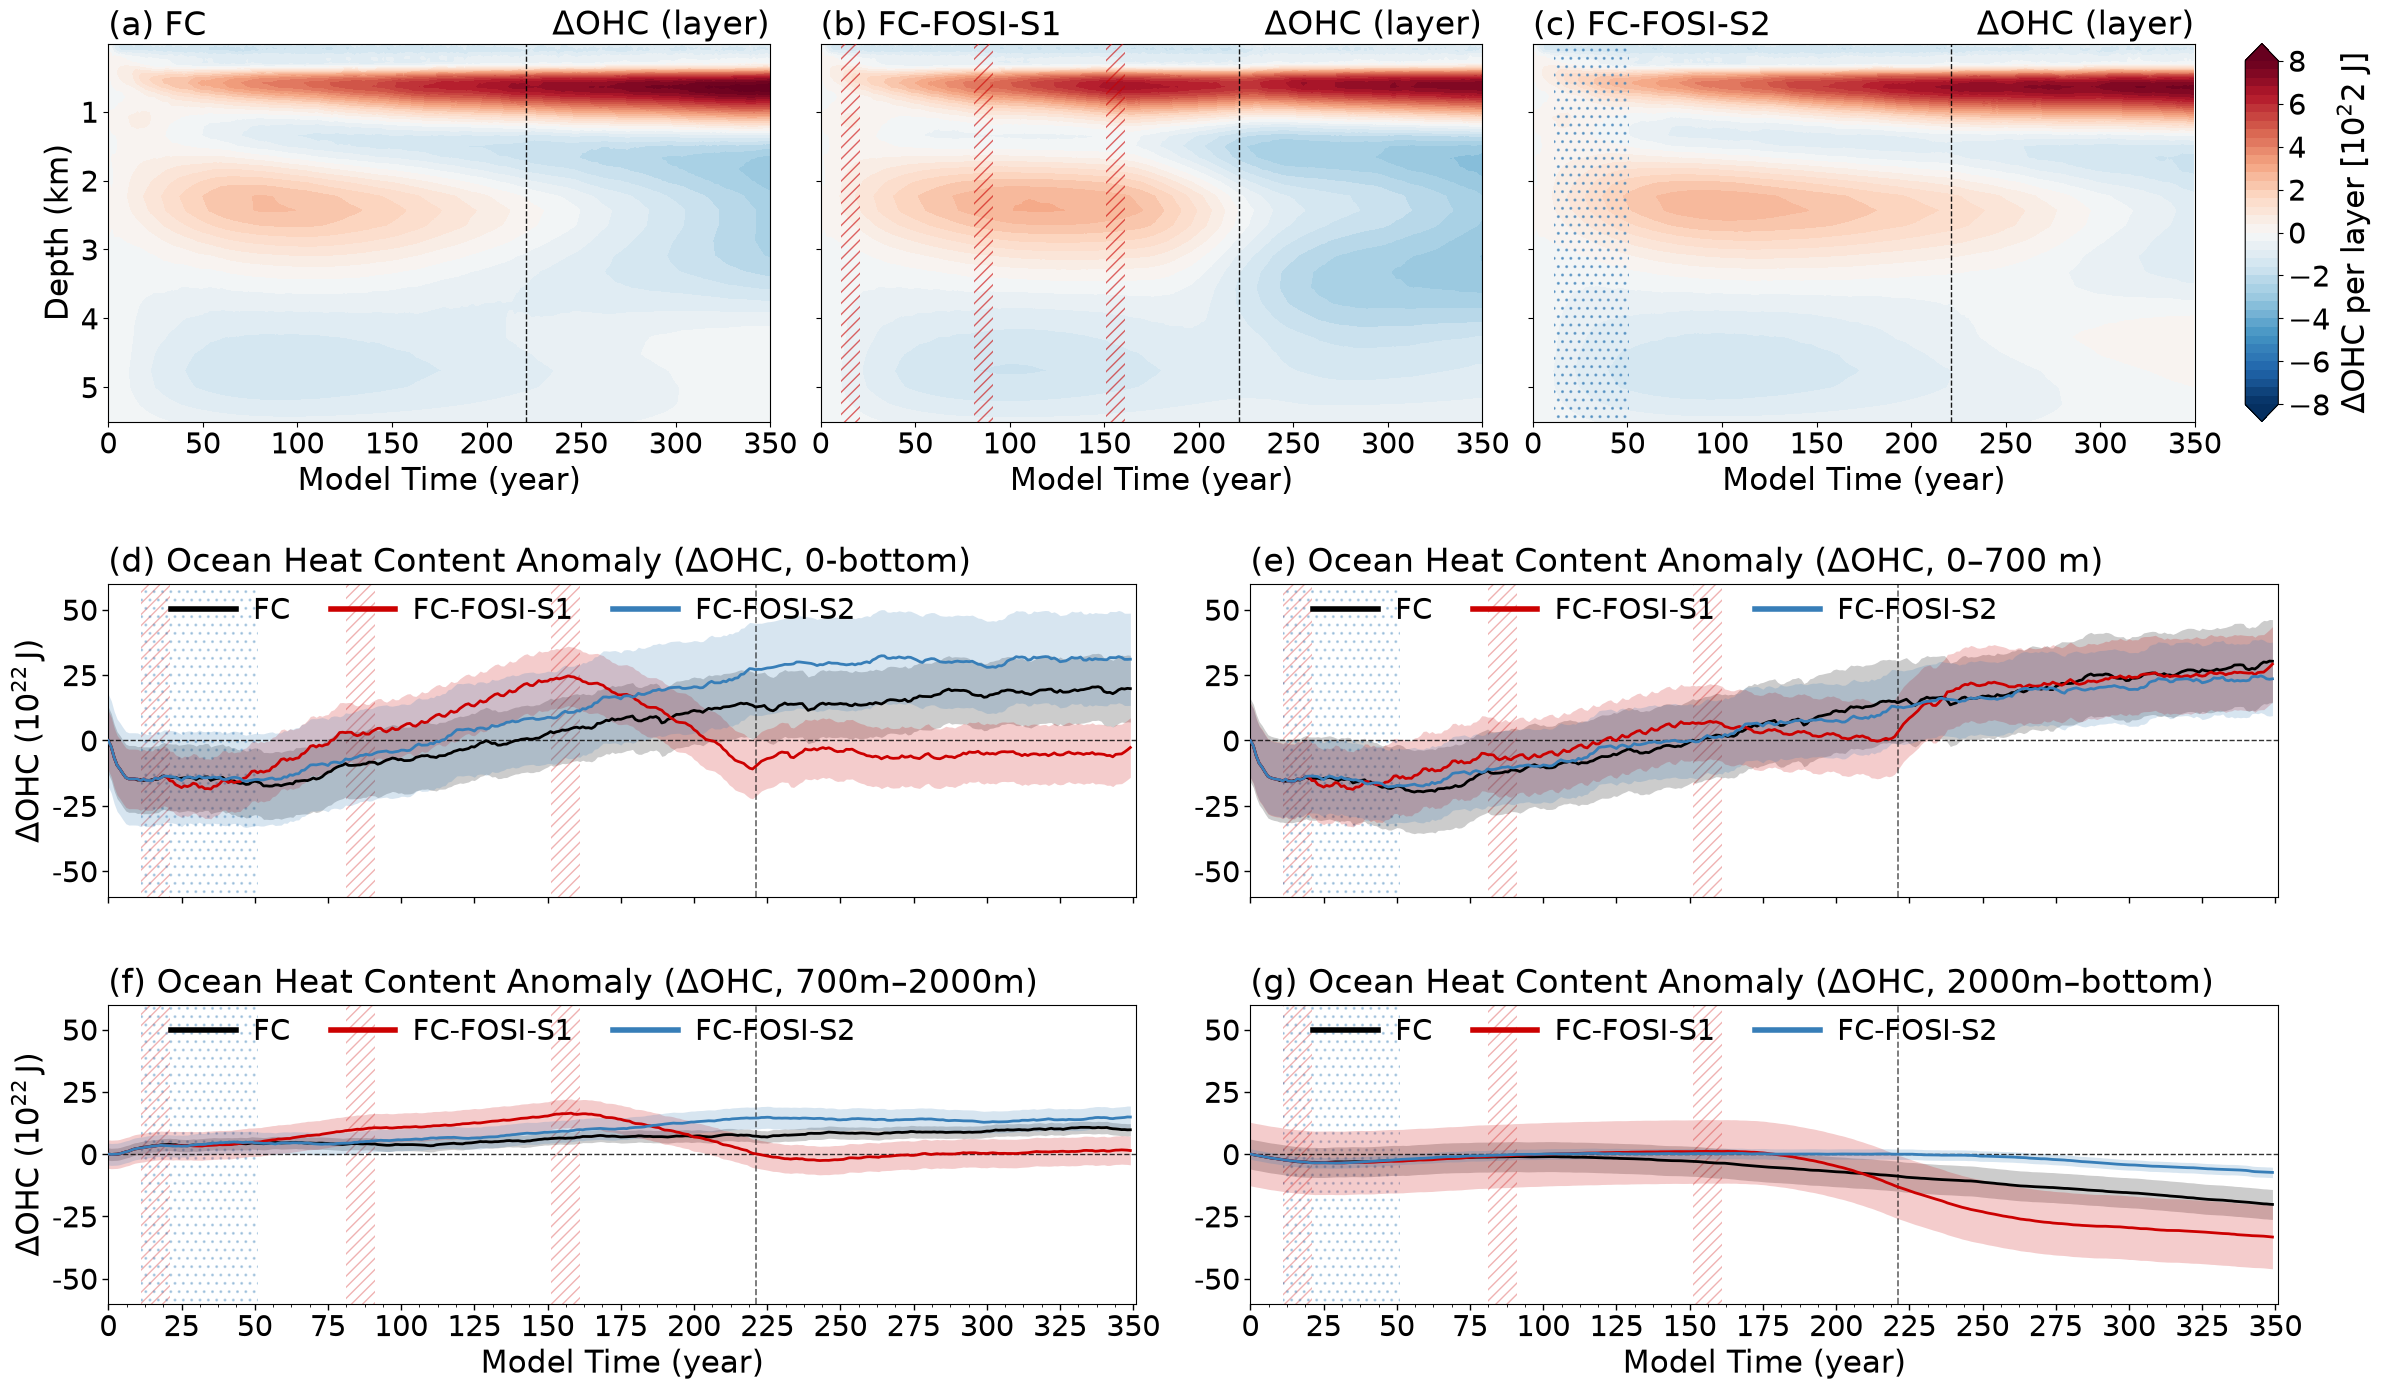

Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc/ocean_ohc_diag_Global_ts_yr0001-0350.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc


In [5]:
# ============================================================
# 1) Build collector (centralizes IO/time defaults)
# ============================================================
collector = OHCFigureDataCollector(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    climo_len=ohc_clim_len,
    ts_base=ohc_ts_base,
    data_dir=data_dir,
    mpas_depth=ohc_depth,
    cfg=OHCFigureDataCollectorConfig(
        file_key=ohc_file_key,
        engine=engine,
        chunks=chunks,
        verbose=verbose,
        calendar=calendar,
        reassign_monthly_time=reassign_monthly_time,
        length_policy=ohc_length_policy,
        annual_mean=ohc_annual_mean,
        annual_weighted=ohc_annual_weighted,
        annual_drop_incomplete=ohc_annual_drop_incomplete,
        annual_min_days=ohc_annual_min_days,
    ),
)

# ============================================================
# 2) Collect (or load) figure data
# ============================================================
if collect_figure_data:
    # ---- TS ----
    ohc_series = collector.collect_ohc_series(
        need_vars=ohc_vars,
        region_key=region_key,
        reg_dim=reg_dim,
        region_index=region_index,
        l_anom=ohc_anomaly,
        to_ZJ=ohc_to_ZJ,
        rho=ohc_rho,
        cp=ohc_cp,
        baseline_months=ohc_base_months,
        use_mask_in_volume=ohc_use_mask_in_volume,
        annual_mean=ohc_annual_mean,
        annual_weighted=ohc_annual_weighted,
        annual_drop_incomplete=ohc_annual_drop_incomplete,
        annual_min_days=ohc_annual_min_days,
        use_mfdataset=use_mfdataset,
        verbose=verbose,
    )

    plot_data = collector.build_plot_data(
        ohc_series,
        plot_vars=list(plot_info.keys()),
        exp_tags=exp_tags,
    )

    # ---- HOV ----
    hov_raw = collector.collect_ohc_hov(
        region_key=region_key,
        reg_dim=reg_dim,               
        region_index=region_index,
        annual_mean=hov_annual_first,
        annual_weighted=hov_annual_weighted,
        annual_drop_incomplete=hov_annual_drop_incomplete,
        annual_min_days=hov_annual_min_days,
        mode=hov_mode,
        to_units=hov_to_units,
        anomaly=hov_anomaly,
        baseline_mode=hov_baseline_mode,
        first_N=hov_baseline_months,
        depth_coord=hov_depth_coord,
        return_cumulative=hov_return_cumulative,
        from_top=hov_from_top,
        use_mask_in_area=hov_use_mask_in_area,
        verbose=verbose,
    )

    # ensure Dataset per exp and ensure hov_key exists
    hov_data = {}
    for exp, obj in hov_raw.items():
        if isinstance(obj, xr.DataArray):
            ds = obj.to_dataset(name=hov_key)
        else:
            ds = obj
        if hov_key not in ds.data_vars and len(ds.data_vars) == 1:
            only = list(ds.data_vars)[0]
            ds = ds.rename({only: hov_key})
        hov_data[exp] = ds

    # ---- Save bundle ----
    collector.save_bundle(
        out_base=out_ncb,
        ts_plot_data=plot_data,
        ts_plot_info=plot_info,
        ts_freq="monthly" if (not ohc_annual_mean) else "annual",
        ts_year_min_for_coords=year_min_plot,
        ts_year_max_for_meta=year_max_plot,
        hov=hov_data,
        hov_key=hov_key,
        meta={
            "region_key": region_key,
            "reg_dim": reg_dim,
            "reg_var": reg_var,
            "calendar": calendar,
            "ts_window_years": f"{year_min}-{year_max}",
            "figure_pdf": os.path.basename(out_pdf),
        },
        compress=True,
    )
    print("Saved bundle base:", out_ncb)

else:
    # ---- Load bundle ----
    bundle = collector.load_bundle(
        out_base=out_ncb,
        ts_var_keys=ohc_vars,      # optional if meta has ts_plot_info
        load_ts=True,
        load_hov=True,
        hov_as_dataset=True,
        hov_key=hov_key,
    )
    plot_data = bundle["ts_plot_data"]
    hov_data  = bundle["hov"]
    plot_info = bundle.get("meta", {}).get("ts_plot_info", None)
    if plot_info is None:
        raise RuntimeError("[load] meta missing ts_plot_info; set collect_figure_data=True once to write meta.")

# ============================================================
# 3) Plot (unchanged plotter usage)
# ============================================================
plot_annual_mean = True
compute_anomaly  = False
running_mean     = False
running_mean_months = 0
use_filter       = False
trend_years      = 100
trend_unit       = "per_decade"

figsize  = (28, 18)
fontsize = 24
step_yrs = 25
ref_yrs  = [hov_spin_year]

ts_hspace  = 0.35
ts_wspace  = 0.25
hov_hspace = 0.35
hov_wspace = 0.10
use_panel_labels = False
sha_alpha = 0.10

plotter = OHCDiagnosticsPlotter(
    year_min=year_min_plot,
    year_max=year_max_plot,
    annual_mean=plot_annual_mean,
    compute_anomaly=compute_anomaly,
    running_mean=running_mean,
    running_mean_months=running_mean_months,
    use_filter=use_filter,
    trend_years=trend_years,
    trend_unit=trend_unit,
)

fig, stats = plotter.plot_ohc_hov_ts_figure(
    plotter=plotter,
    hov_data=hov_data,
    ts_plot_data=plot_data,
    exp_order=exp_tags,
    exp_labels=labels,
    colors=ts_colors,
    ts_var_keys=ohc_vars,
    ts_plot_info=plot_info,
    exp_shas=exp_shas,
    sha_alpha=sha_alpha,
    hov_key=hov_key,
    cmap=hov_cmap,
    vmin=hov_vmin,
    vmax=hov_vmax,
    ref_yrs=ref_yrs,
    step_yrs=step_yrs,
    fontsize=fontsize,
    figsize=figsize,
    outpath=out_pdf,
    hov_spin_year=ref_yrs[0],
    ts_hspace=ts_hspace,
    ts_wspace=ts_wspace,
    hov_hspace=hov_hspace,
    hov_wspace=hov_wspace,
    use_panel_labels=use_panel_labels,
)
plt.show()
plt.close(fig)
print("Saved figure:", out_pdf)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
